***In order to subimt your assigment, please follow these instructions carefully:***

1. It's recommended to run this notebook in the DOORS platform, or, if you know what you're doing (or need another module, though you can also locally install modules with `!pip install`, but beware that they might disappear). (It is not necessary to install new packages, but you can if you find them useful for the completion of this assignment.
2. Once you are done with the assignment, make sure to restart the Kernel and run all to ensure that eveything runs in sequence and that you don't have errors.
3. When you're done with the steps, save the notebook and also save the notebook as PDF (File > Save/Export (depnding on the Jupyter version) > PDF). Upload the PDF in UNESS. You can also upload the ipynb once you've saved it (you can get it from File > Download).

***Please don't forget to tell me who you are:***

**NAME: Thanh-Phuong VO**

**EMAIL: Thanh-Phuong.Vo@etu.univ-grenoble-alpes.fr; 0001thanhphuong@gmail.com**


Notes:
- While doing this assigment, try also to go a bit "beyond" what's being asked, i.e. show the process which you follow and how you approach the problem.
- Look online for ways to get what you want from insights (i.e. how to check a model's performance while training)
- Feel free to check other tutorials and assignments to get ideas for algorithms
- If you copy something from somewhere, you should reference it properly and explain what it does (also for your code)

In this tutorial, we'll use the [mobile health (MHEALTH) dataset](https://archive.ics.uci.edu/ml/datasets/MHEALTH+Dataset).

The goal is to predict the activity that people are doing based on the measurements from 23 channels (device outputs).



In [1]:
! [ ! -f MHEALTHDATASET.zip ] && wget https://archive.ics.uci.edu/ml/machine-learning-databases/00319/MHEALTHDATASET.zip || echo "Data already downloaded!"
! [ -d MHEALTHDATASET ] && echo "Data already extracted" || unzip MHEALTHDATASET.zip
! ls
! ls MHEALTHDATASET


# Let us get some information on the dataset

with open("MHEALTHDATASET/README.txt", encoding = "ISO-8859-1") as f:
  for l in f.readlines(): print(l)

Data already downloaded!
Data already extracted
01_Supervised_Learning_Classification.ipynb  data
02_Unsupervised_Learing_Clustering.ipynb     MHEALTHDATASET
03_A_Medical_Dataset.ipynb		     MHEALTHDATASET.zip
04_Stroke_Prediction.ipynb		     Untitled.ipynb
binder
mHealth_subject10.log  mHealth_subject4.log  mHealth_subject8.log
mHealth_subject1.log   mHealth_subject5.log  mHealth_subject9.log
mHealth_subject2.log   mHealth_subject6.log  README.txt
mHealth_subject3.log   mHealth_subject7.log


*************************************************** mHealth dataset **********************************************************



Authors: Oresti Baños, Rafael Garcia, Alejandro Saez

Date: 22/10/2013

Institution: University of Granada (UGR) 

Department: Department of Computer Architecture and Computer Technology.

Contact: oresti@ugr.es (oresti.bl@gmail.com)



--------------------------------------------------------------------------------------------------------------------------------------

Let us know have a look at the data output, to understand what we're dealing with. This image helps explain what we do: we make shorter sequences of 100 points (2s @ 50Hz) that we'll use to train.

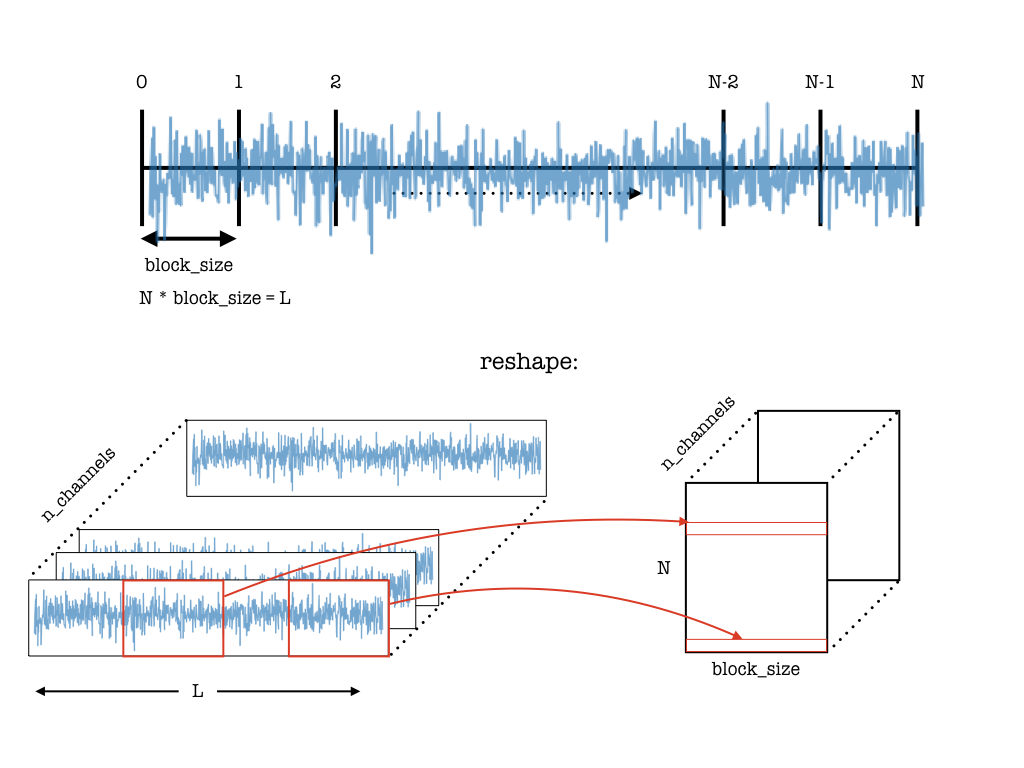


In [2]:
import pandas as pd
import numpy as np

def read_subject(i):
  print(f"Processing file MHEALTHDATASET/mHealth_subject{i}.log")
  data = pd.read_csv(f"MHEALTHDATASET/mHealth_subject{i}.log", delimiter='\t',header=None)
  # Removing null class
  data = data[data[23]!=0]
  return data

# Let's make blocks of 100 points (i.e. 2s worth of points)
def split_in_blocks(data, block_size=100):
  X_ = []
  y_ = []

  groups = data.groupby(23)
  n_channels = data.shape[1]-1

  for gid in range(1,len(groups)+1):
    y = pd.unique(groups.get_group(gid)[23].to_numpy())
    x = groups.get_group(gid).drop(23, axis=1).to_numpy()
    n_blocks = len(x) // block_size

    x = x[:n_blocks*block_size]
    y = y[:n_blocks*block_size]

    x_tensor = x.reshape(-1, block_size, n_channels)

    # Append
    X_.append(x_tensor)
    y_.append(np.array([y]*len(x_tensor), dtype=int).squeeze())

  # Concatenate and return
  X = np.concatenate(X_, axis=0)
  y = np.concatenate(y_, axis=0)
  return X, y

block_size = 100
# Creating lists to save data
X_ = []
y_ = []
for s in range(1,11):
  data = read_subject(s)
  X, y = split_in_blocks(data, block_size)
  X_.append(X)
  y_.append(y)
# Concatenate
X = np.concatenate(X_, axis=0)
y = np.concatenate(y_, axis=0)

print(X.shape, y.shape)

# Code to bring everything in in one go
# data_list = []
# for i in range(1,11):
#   data = read_subject(i)
#   data_list.append( data )
# data = pd.concat(data_list, axis=0, ignore_index=True)
# print(data.head())
# # Checking the shape of our data
# print(data.shape)
# for i in range(1,13):
#   print(f"{i}: {data[data[23]==i].shape}")

Processing file MHEALTHDATASET/mHealth_subject1.log
Processing file MHEALTHDATASET/mHealth_subject2.log
Processing file MHEALTHDATASET/mHealth_subject3.log
Processing file MHEALTHDATASET/mHealth_subject4.log
Processing file MHEALTHDATASET/mHealth_subject5.log
Processing file MHEALTHDATASET/mHealth_subject6.log
Processing file MHEALTHDATASET/mHealth_subject7.log
Processing file MHEALTHDATASET/mHealth_subject8.log
Processing file MHEALTHDATASET/mHealth_subject9.log
Processing file MHEALTHDATASET/mHealth_subject10.log
(3355, 100, 23) (3355,)


Now that `X` represents the data from the 23 channels and the `y` the activity identifier (from 1 to 12), we can use the dataset.

We now need to split our data between the *training* and *testing* samples.
(We might even go further as we have a lot of data points.)

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, stratify=y, random_state=123)

# Standardize
def standardise(X): return (X - np.mean(X, axis=0)[None,:,:]) / np.std(X, axis=0)[None,:,:]

X_train = standardise(X_train)
X_test = standardise(X_test)

# Train/validation
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.4, stratify=y_train, random_state=456)

# One-hot encoding
def one_hot(labels, n_class): return np.eye(n_class)[:,labels-1].T

y_train = one_hot(y_train, n_class=12)
y_valid = one_hot(y_valid, n_class=12)
y_test = one_hot(y_test, n_class=12)

# Getting some numbers out
print("Training set size: ", len(X_train))
print("Validaton set size: ", len(X_valid))
print("Test set size: ", len(X_test))

Training set size:  1408
Validaton set size:  940
Test set size:  1007


Let us now train a network

In [4]:
import tensorflow as tf
from tensorflow import keras
from keras import layers

num_classes = 12
input_shape = (block_size, 23, 1)
print(input_shape)
model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

# Shows a nice summary of the model
model.summary()

!pip install pydot
from tensorflow.keras.utils import plot_model

plot_model(model, 'CNN-Model.png', show_shapes=True)

2025-12-22 18:11:35.886376: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-22 18:11:35.929798: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-22 18:11:35.929851: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-22 18:11:35.931412: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-22 18:11:35.939014: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-22 18:11:35.939951: I tensorflow/core/platform/cpu_feature_guard.cc:1

(100, 23, 1)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 98, 21, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 49, 10, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 47, 8, 64)         18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 23, 4, 64)         0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 21, 2, 64)         36928     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 10, 1, 

Let's train our network.

In [5]:
batch_size = 128
epochs = 20

# Feel free to change parameters below if needed
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

Epoch 1/20
10/10 [==============================] - 5s 412ms/step - loss: 2.2974 - accuracy: 0.1713 - val_loss: 2.2000 - val_accuracy: 0.1489
Epoch 2/20
10/10 [==============================] - 4s 378ms/step - loss: 1.9905 - accuracy: 0.2739 - val_loss: 1.8984 - val_accuracy: 0.3972
Epoch 3/20
10/10 [==============================] - 4s 378ms/step - loss: 1.7192 - accuracy: 0.3844 - val_loss: 1.5420 - val_accuracy: 0.5745
Epoch 4/20
10/10 [==============================] - 4s 357ms/step - loss: 1.4114 - accuracy: 0.5343 - val_loss: 1.2071 - val_accuracy: 0.6525
Epoch 5/20
10/10 [==============================] - 4s 356ms/step - loss: 1.1286 - accuracy: 0.6409 - val_loss: 0.9632 - val_accuracy: 0.7376
Epoch 6/20
10/10 [==============================] - 4s 355ms/step - loss: 0.8509 - accuracy: 0.7340 - val_loss: 0.6394 - val_accuracy: 0.8582
Epoch 7/20
10/10 [==============================] - 3s 345ms/step - loss: 0.6919 - accuracy: 0.7703 - val_loss: 0.5478 - val_accuracy: 0.8014
Epoch 

Let us plot the performance of our algorithm.

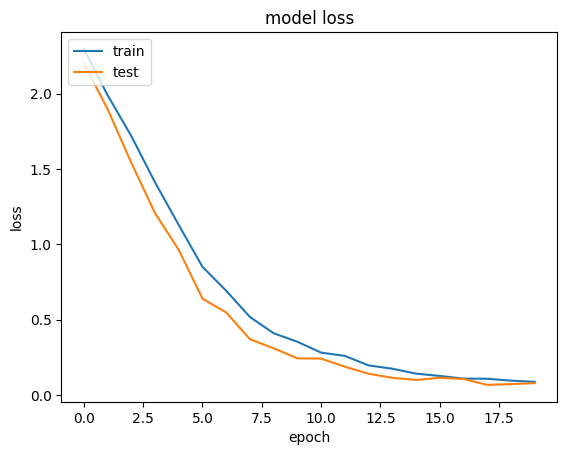

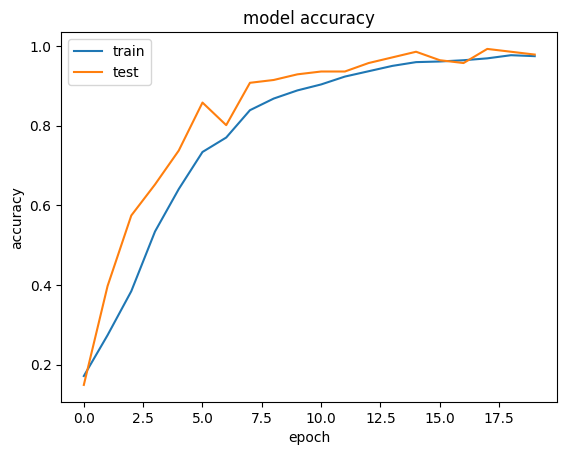

In [6]:
def plot_history(history):
  import matplotlib.pyplot as plt
  %matplotlib inline

  for k in [ 'loss', 'accuracy']:
    # summarize history for accuracy
    plt.plot(history.history[f'{k}'])
    plt.plot(history.history[f'val_{k}'])
    plt.title(f'model {k}')
    plt.ylabel(f'{k}')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()

plot_history(history)

Q1 [3 pts] Please provide some information on the performance of your model and a training.

**Answer:**

- The training curves show a steady decrease in loss and an increase in accuracy over epochs.
- Train and validation curves remain close in both the loss and accuracy plots, suggesting stable learning and no obvious overfitting within 20 epochs. 
- Final performance including accuracy and confusion matrices:
    - The accuracies of validation, test and all data are roughly above 96.5%, 97,0%, 97.6%, respectively.
    - The confusion matrices are strongly diagonal, meeaning most samples are correctly classified. The remaining errors are concentrated in a small number of off-diagonal cells, indicating that misclassifications are not random but occur mainly between a few similar classes.

Overall, the combination of stable learning curves and high and consistent accuracies on validation/test indicates the model trained effectively and generalizes well on this windowed MHEALTH classification task.

Obtaining the confusion matrix for the model.


32/32 [==============================] - 1s 20ms/step
Correcly classified 975 out of 1007 sequences (96.8222442899702%)


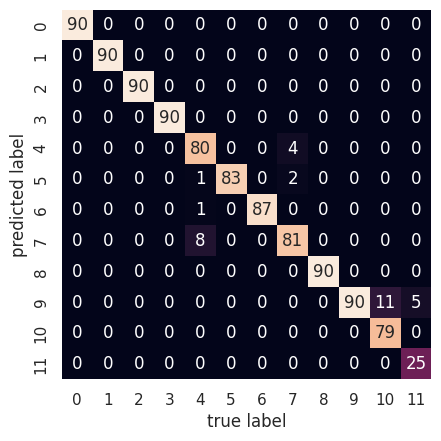

30/30 [==============================] - 1s 19ms/step
Correcly classified 907 out of 940 sequences (96.48936170212767%)


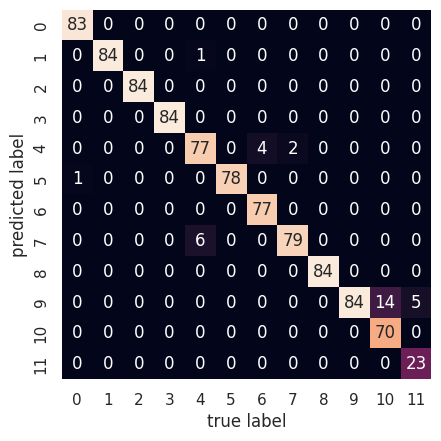

105/105 [==============================] - 2s 20ms/step
Correcly classified 3274 out of 3355 sequences (97.58569299552906%)


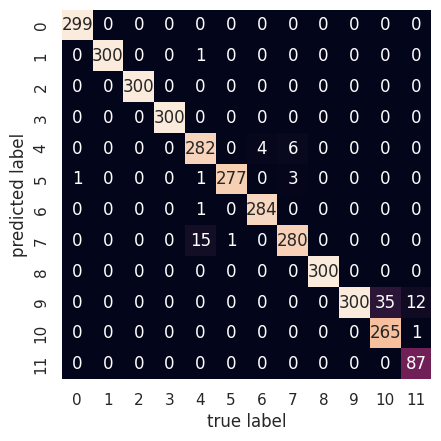

In [7]:
def analyse_classifier(model, X, y):
  yPred = model.predict(X, verbose=1)
  from sklearn.metrics import confusion_matrix
  # Don't forget that in our model we have labels from 1 to 12
  cm = confusion_matrix(y.argmax(axis=1)+1, yPred.argmax(axis=1)+1)

  import matplotlib.pyplot as plt
  %matplotlib inline
  import seaborn as sns; sns.set()
  sns.heatmap(cm.T, square=True, annot=True, fmt='d', cbar=False)
  plt.xlabel('true label')
  plt.ylabel('predicted label');
  nTotal = len(y)
  nCorrect = np.count_nonzero(y.argmax(axis=1)-yPred.argmax(axis=1)==0)
  print(f"Correcly classified {nCorrect} out of {nTotal} sequences ({nCorrect/nTotal*100}%)")

  plt.show()

analyse_classifier(model, X_test, y_test)
analyse_classifier(model, X_valid, y_valid)

# Running on the complete dataset
# We first need to standardise our input (which we didn't do before)
X_std = standardise(X)
# And we need to conver the full y into one-hot notation
analyse_classifier(model, X_std, one_hot(y, n_class=12))

## Training another classifier

Q2 [4 pts] Can you train another model ?

**Answer:**
In this notebook, both validation and test sets are used as post-training evaluation sets (via analyse_classifier). The validation set is not used for model selection during training.

I trained a second CNN model with increased the number of filters in the third convolutional layer from 64 to 128 (filters 32 → 64 → 128), and keeping the same optimizer/loss, batch_size=128, and 20 epochs.

The model shows a small but consistent improvement in classification performance. 
- The accuracies of validation and test are roughly above 97.5%, and and all data are 98.45%.
- The confusion matrices remain strongly diagonal, indicating that most activities are well separated and that the remaining errors are limited to a few visually similar classes.

This improvement is expected because increasing the number of filters increases the model’s representational capacity at deeper levels of the network. After several pooling operations, the feature maps become more compressed; adding more filters helps the network preserve and learn richer high-level patterns by allocating more channels to capture subtle time–sensor interactions. As a result, the classifier can better discriminate between activities with similar sensor signatures.

Feel free to split into multiple text/code blocks as needed.

In [8]:
num_classes = 12
input_shape = (block_size, 23, 1)
print(input_shape)
model_2 = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(128, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        # layers.Conv2D(256, kernel_size=(3, 3), activation="relu"),
        # layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

# Shows a nice summary of the model
model_2.summary()

!pip install pydot
from tensorflow.keras.utils import plot_model

plot_model(model_2, 'CNN-Model.png', show_shapes=True)

(100, 23, 1)
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 98, 21, 32)        320       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 49, 10, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 47, 8, 64)         18496     
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 23, 4, 64)         0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 21, 2, 128)        73856     
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 10, 1

In [9]:
batch_size = 128
epochs = 20

# Feel free to change parameters below if needed
model_2.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history_2 = model_2.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

Epoch 1/20
10/10 [==============================] - 5s 400ms/step - loss: 2.2801 - accuracy: 0.1539 - val_loss: 2.1061 - val_accuracy: 0.2482
Epoch 2/20
10/10 [==============================] - 4s 367ms/step - loss: 1.8343 - accuracy: 0.3157 - val_loss: 1.6606 - val_accuracy: 0.4610
Epoch 3/20
10/10 [==============================] - 4s 377ms/step - loss: 1.5044 - accuracy: 0.4846 - val_loss: 1.3284 - val_accuracy: 0.5816
Epoch 4/20
10/10 [==============================] - 4s 378ms/step - loss: 1.1720 - accuracy: 0.6101 - val_loss: 0.9223 - val_accuracy: 0.7305
Epoch 5/20
10/10 [==============================] - 4s 368ms/step - loss: 0.8674 - accuracy: 0.6875 - val_loss: 0.6396 - val_accuracy: 0.8156
Epoch 6/20
10/10 [==============================] - 4s 377ms/step - loss: 0.6095 - accuracy: 0.8082 - val_loss: 0.4929 - val_accuracy: 0.8511
Epoch 7/20
10/10 [==============================] - 4s 367ms/step - loss: 0.5506 - accuracy: 0.8200 - val_loss: 0.4719 - val_accuracy: 0.8369
Epoch 

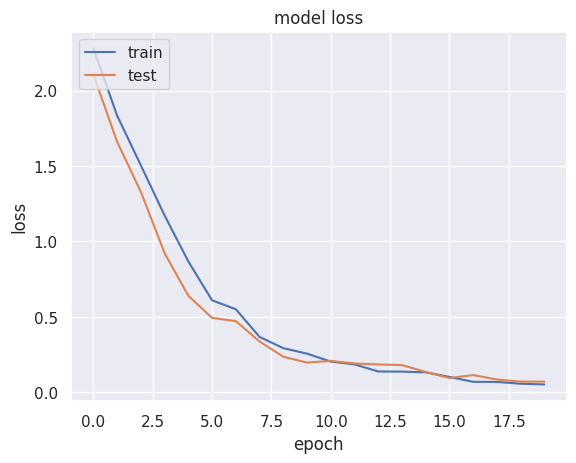

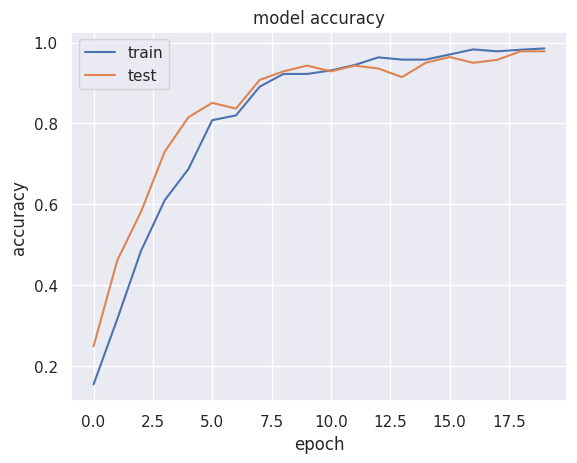

In [10]:
plot_history(history_2)

32/32 [==============================] - 1s 22ms/step
Correcly classified 994 out of 1007 sequences (98.7090367428004%)


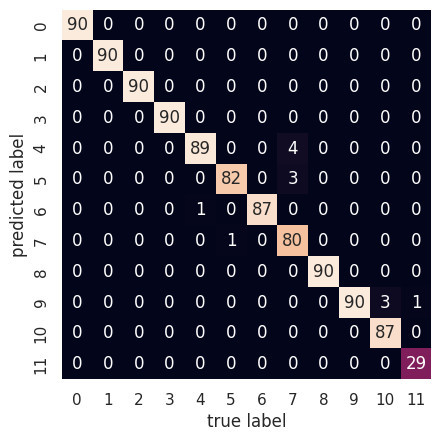

30/30 [==============================] - 1s 19ms/step
Correcly classified 922 out of 940 sequences (98.08510638297872%)


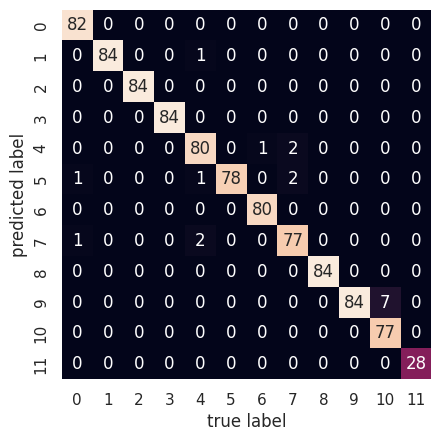

105/105 [==============================] - 2s 22ms/step
Correcly classified 3319 out of 3355 sequences (98.92697466467958%)


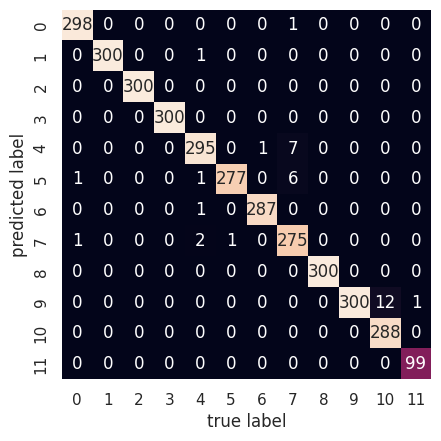

In [11]:
analyse_classifier(model_2, X_test, y_test)
analyse_classifier(model_2, X_valid, y_valid)

# And we need to conver the full y into one-hot notation
analyse_classifier(model_2, X_std, one_hot(y, n_class=12))

Q3 [4 pts] Can you try yet another ?

Try varying the parameters (copying to yet another cell ; don't forget to adjust the model variable to `model_3` or more).

**Answer:**
The model 3: third convolutional layer increased to 128 filters, dropout = 0.8, and 25 epochs.
Initially, for this model 3, I used third convolutional layer increased to 128 filters, dropout = 0.8, and 20 epochs. The performance of model training and test didn't change significantly comparing to model 2 (third convolutional layer increased to 128 filters, dropout = 0.5, and 20 epochs).

After that, I increased the epoch into 25 epochs (third convolutional layer increased to 128 filters, dropout = 0.8, and 25 epochs):
- The CNN achieves high and stable performance. The learning curves show a consistent decrease in loss across epochs and a steady increase in accuracy, with the train and test/validation curves remaining close, which suggests good generalization rather than severe overfitting. 
- Final results confirm this: the model correctly classified 990/1007 test sequences (98.31%), and 924/940 sequences (98.30%), and reached 3316/3355 sequences (98.84%) when evaluated on the complete dataset.
- The confusion matrices remain strongly diagonal, indicating that most activity classes are well separated and that the remaining errors are limited to a small number of confusions between similar activities.

This behavior is consistent with the role of the three changes:
- Increasing the depth capacity at the third convolutional block (128 filters) allows the network to learn richer high-level representations after repeated pooling, which can improve discrimination between subtle patterns.
- At the same time, using a high dropout rate (0.8) acts as strong regularization: it prevents the model from relying on a small set of features and encourages more robust, distributed representations, which typically improves generalization on held-out data.
- Training for 25 epochs gives the model enough time to converge under this stronger regularization, explaining why performance remains high without a clear overfitting trend.

In [12]:
# Put your code here to train and evaluate another model (next cell)

# Model definition
# model_2 =

# Training

# batch_size = XX
# epochs = XX
# model_2.compile(loss="...", optimizer="...", metrics=["accuracy"])
# history = model_2.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=XX)

num_classes = 12
input_shape = (block_size, 23, 1)
print(input_shape)
model_3 = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(128, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        # layers.Conv2D(256, kernel_size=(3, 3), activation="relu"),
        # layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.8),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

# Shows a nice summary of the model
model_3.summary()

!pip install pydot
from tensorflow.keras.utils import plot_model

plot_model(model_3, 'CNN-Model.png', show_shapes=True)

batch_size = 128
epochs = 25

# Feel free to change parameters below if needed
model_3.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history_3 = model_3.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

(100, 23, 1)
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 98, 21, 32)        320       
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 49, 10, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_7 (Conv2D)           (None, 47, 8, 64)         18496     
                                                                 
 max_pooling2d_7 (MaxPoolin  (None, 23, 4, 64)         0         
 g2D)                                                            
                                                                 
 conv2d_8 (Conv2D)           (None, 21, 2, 128)        73856     
                                                                 
 max_pooling2d_8 (MaxPoolin  (None, 10, 1

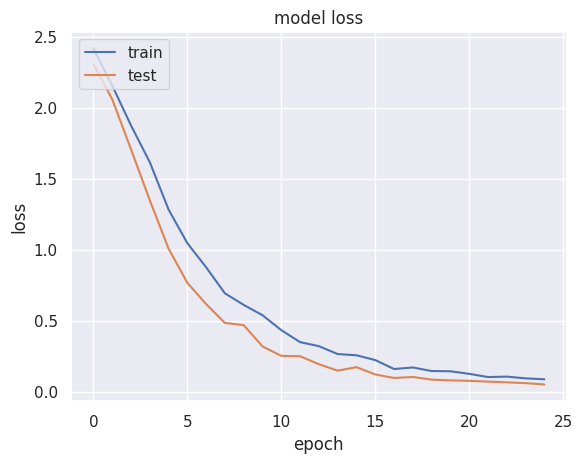

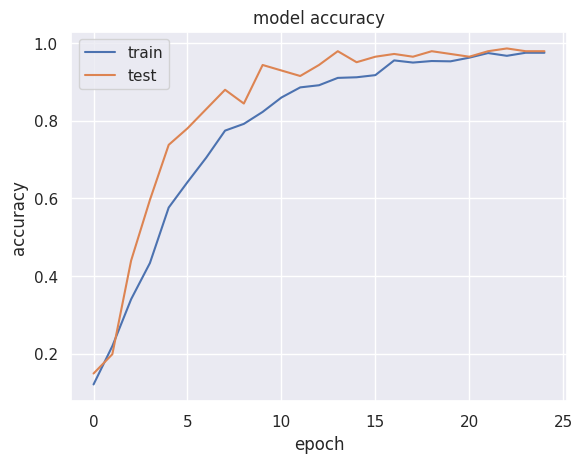

In [13]:
plot_history(history_3)

Evaluation

32/32 [==============================] - 1s 23ms/step
Correcly classified 989 out of 1007 sequences (98.21251241310824%)


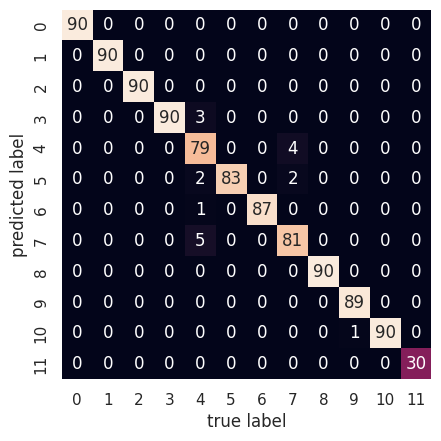

30/30 [==============================] - 1s 22ms/step
Correcly classified 927 out of 940 sequences (98.61702127659574%)


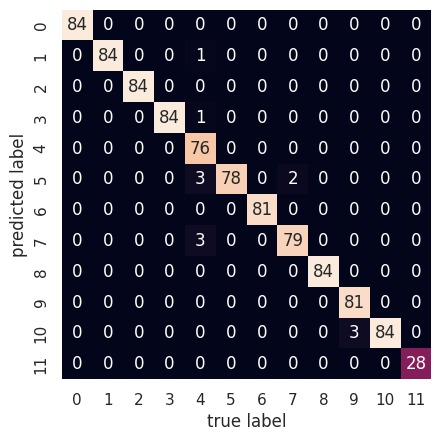

105/105 [==============================] - 2s 22ms/step
Correcly classified 3319 out of 3355 sequences (98.92697466467958%)


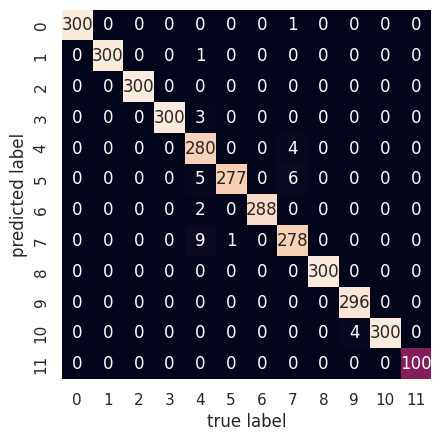

In [14]:
analyse_classifier(model_3, X_test, y_test)
analyse_classifier(model_3, X_valid, y_valid)

# And we need to conver the full y into one-hot notation
analyse_classifier(model_3, X_std, one_hot(y, n_class=12))

### Yet another model

Q4 [4 pts] Train another model

**Answer:**

`model_4`
Using the same CNN architecture with 128 filters in the third convolutional block and dropout = 0.5, but switching the optimizer from Adam to RMSprop, the model achieves noticeably lower final accuracy. 

Final results confirm this: the model correctly classified 972/1007 test sequences (96.52%) and 910/940 validation sequences (96.81%), with 3279/3355 correct predictions (97.73%) on the complete dataset. Although the training curves still show smooth convergence (loss decreases and accuracy increases over epochs), the confusion matrices reveal larger off-diagonal errors for a few classes, indicating weaker class separation than the Adam-based model. 
I have trained the model with increasing training from 20 to 25 epochs, but the result does not significantly improve, suggesting that the model has largely plateaued under this optimization setting.

A plausible explanation is that Adam tends to converge more reliably with default settings because it automatically adjusts the learning rate for each parameter while also using momentum-like updates. This makes training more stable under mini-batch noise and helps the model reach a better solution faster. In contrast, RMSprop is more sensitive to its hyperparameters (especially the learning rate), and with the default values it may not move toward the best minimum as effectively. As a result, RMSprop can end up with a slightly worse final solution, which explains why the validation/test accuracy stays lower even when increasing the number of epochs.

In [15]:
# Put your code here to train and evaluate another model (next cell)

# Model definition
# model_3 =

# Training

# batch_size = XX
# epochs = XX
# model_3.compile(loss="...", optimizer="...", metrics=["accuracy"])
# history = model_3.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=XX)
num_classes = 12
input_shape = (block_size, 23, 1)
print(input_shape)
model_4 = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(128, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

# Shows a nice summary of the model
model_4.summary()

!pip install pydot
from tensorflow.keras.utils import plot_model

plot_model(model_4, 'CNN-Model.png', show_shapes=True)

batch_size = 128
epochs = 25

# Feel free to change parameters below if needed
model_4.compile(loss="categorical_crossentropy", optimizer="RMSprop", metrics=["accuracy"])
history_4 = model_4.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

(100, 23, 1)
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 98, 21, 32)        320       
                                                                 
 max_pooling2d_9 (MaxPoolin  (None, 49, 10, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_10 (Conv2D)          (None, 47, 8, 64)         18496     
                                                                 
 max_pooling2d_10 (MaxPooli  (None, 23, 4, 64)         0         
 ng2D)                                                           
                                                                 
 conv2d_11 (Conv2D)          (None, 21, 2, 128)        73856     
                                                                 
 max_pooling2d_11 (MaxPooli  (None, 10, 1

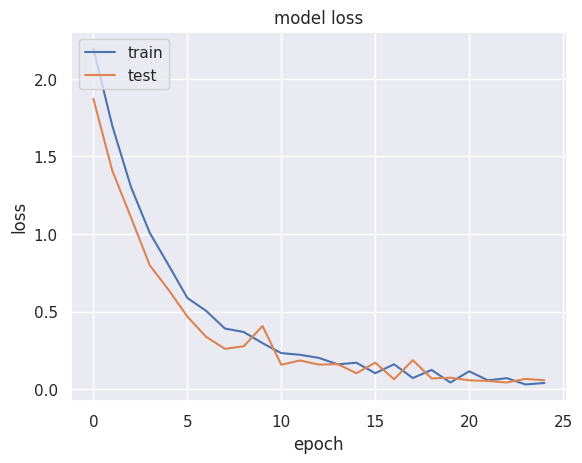

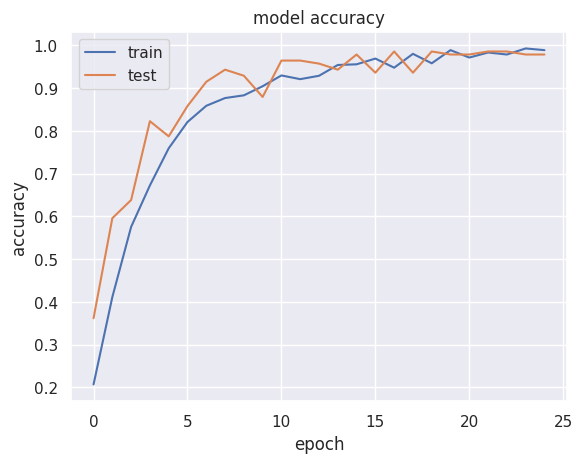

In [16]:
plot_history(history_4)

Evaluation

32/32 [==============================] - 1s 22ms/step
Correcly classified 991 out of 1007 sequences (98.41112214498511%)


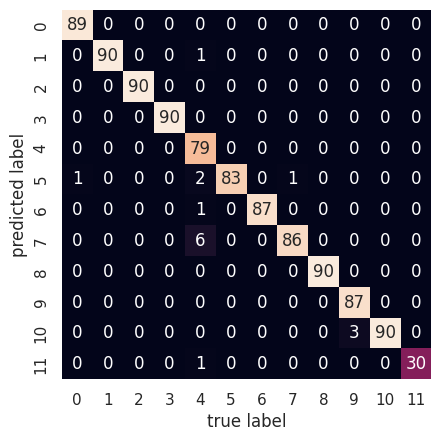

30/30 [==============================] - 1s 20ms/step
Correcly classified 926 out of 940 sequences (98.51063829787235%)


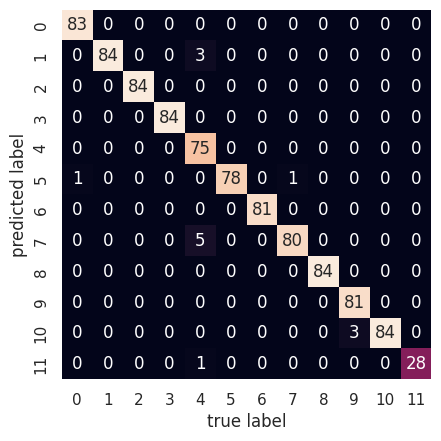

105/105 [==============================] - 2s 22ms/step
Correcly classified 3317 out of 3355 sequences (98.86736214605068%)


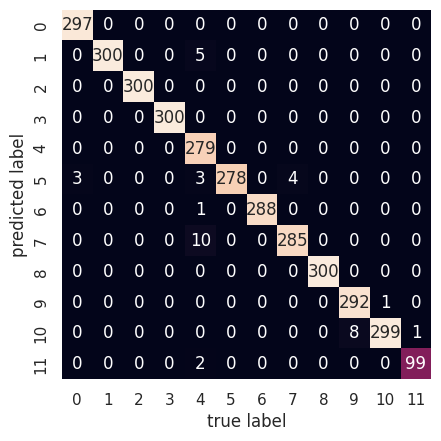

In [17]:
analyse_classifier(model_4, X_test, y_test)
analyse_classifier(model_4, X_valid, y_valid)

# And we need to conver the full y into one-hot notation
analyse_classifier(model_4, X_std, one_hot(y, n_class=12))

# Wrapping up

*Note: use this space for thoughts; this part is not part of the mark (unless you don't fill it at all).*

What did you take out from this?

**Answer:**

From this assigment, I understanded how an end-to-end deep learning pipeline is built for wearable multi-sensor activity recognition (MHEALTH), from raw logs to a validated classifier. 

I learned that the quality of the final model depends at least as much on data preparation and evaluation design as on the neural network itself. In particular, converting continuous sensor streams into fixed-length windows (e.g., 100 time steps × 23 channels) is a key step that turns the problem into a supervised classification task with a consistent input shape. I also reinforced why preprocessing matters: applying standardization and using one-hot encoding for the 12 activity classes aligns the data with the assumptions of the optimizer and the categorical cross-entropy loss, and makes training more stable. 

From the modeling side, I observed how architectural and training choices affect performance in practice. A baseline CNN (Conv blocks + pooling + dropout + softmax) already reached strong results, and the learning curves (loss decreasing / accuracy increasing) helped me verify that the model converges properly rather than memorizing. The confusion matrices were especially informative: even when overall accuracy is high, they reveal which classes remain difficult and where errors concentrate, which is more actionable than accuracy alone. 

Most importantly, by training multiple variants, I saw that improvements are often incremental but explainable. Increasing representational capacity (e.g., raising the third convolution layer from 64 to 128 filters) slightly improved validation/test accuracy, consistent with the idea that deeper layers benefit from more filters after repeated pooling. In contrast, changing the optimizer to RMSprop (with otherwise similar settings) led to lower accuracy than Adam, highlighting that optimizers can reach different solutions under default hyperparameters. I also learned that stronger regularization (e.g., higher dropout with enough epochs) can maintain good generalization, but any gain should be interpreted cautiously because results can vary due to randomness in training and the specific validation split. 

Overall, the assignment helped me build intuition for the full workflow: windowing → scaling/encoding → splitting → training → curve-based monitoring → confusion-matrix diagnosis → controlled model comparisons.